In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv, global_add_pool
from pymatgen.core import Structure
from scipy.spatial.distance import cdist
from matbench.bench import MatbenchBenchmark
from sklearn.metrics import mean_absolute_error
import math
np.math = math

# Load Matbench dataset
mb = MatbenchBenchmark(autoload=False)
task = mb.matbench_phonons
task.load()

print(f"✅ Dataset: {len(task.df)} samples")
print(f"   Target range: [{task.df['last phdos peak'].min():.1f}, {task.df['last phdos peak'].max():.1f}] cm⁻¹")

c:\Users\Victor\.conda\envs\pytorch-matbench\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-10-11 14:03:38 INFO     Initialized benchmark 'matbench_v0.1' with 13 tasks: 
['matbench_dielectric',
 'matbench_expt_gap',
 'matbench_expt_is_metal',
 'matbench_glass',
 'matbench_jdft2d',
 'matbench_log_gvrh',
 'matbench_log_kvrh',
 'matbench_mp_e_form',
 'matbench_mp_gap',
 'matbench_mp_is_metal',
 'matbench_perovskites',
 'matbench_phonons',
 'matbench_steels']
2025-10-11 14:03:38 INFO     Loading dataset 'matbench_phonons'...
2025-10-11 14:03:38 INFO     Loading dataset 'matbench_phonons'...
2025-10-11 14:03:39 INFO     Dataset 'matbench_phonons loaded.
✅ Dataset: 1265 samples
   Target range: [59.6, 3643.7] cm⁻¹
2025-10-11 14:03:39 INFO     Dataset 'matbench_phonons loaded.
✅ Dataset: 1265 samples
   Target range: [59.6, 3643.7] cm⁻¹


In [3]:
# Load periodic table (76 features per element)
df_ptable = pd.read_csv('ptable.csv')
df_ptable.fillna(0, inplace=True)
df_ptable.drop(['electronic_configuration', 'name', 'block', 'lattice_structure', 'is_radioactive'], 
               axis=1, inplace=True, errors='ignore')

n_features = len(df_ptable.columns) - 1  # Exclude 'symbol' column
print(f"✅ Loaded ptable: {n_features} features/atom")

✅ Loaded ptable: 76 features/atom


In [33]:
def structure_to_graph(structure, target_value, df_ptable):
    """Convert crystal structure to fully connected graph with 76 features/node"""
    # ساخت supercell 3x3x3
    structure = structure.copy()
    structure.make_supercell([3, 3, 3])
    
    # Extract node features (76 features per atom)
    node_features = []
    atomic_numbers = []
    
    for site in structure.sites:
        Z = site.specie.Z
        atomic_numbers.append(Z)
        # Get features using atomic number as index (Z=1 → row 0)
        features = df_ptable.iloc[Z - 1, 1:].values.astype(np.float32)
        node_features.append(features)
    
    x = torch.tensor(node_features, dtype=torch.float)
    z = torch.tensor(atomic_numbers, dtype=torch.long)
    
    # Positions
    positions = np.array([site.coords for site in structure.sites])
    pos = torch.tensor(positions, dtype=torch.float)
    
    # Edges با cutoff 5 انگستروم در کل supercell
    distances = cdist(positions, positions)
    edge_index = []
    edge_attr = []
    
    cutoff = 5  # انگستروم
    
    n_atoms = len(positions)
    for i in range(n_atoms):
        for j in range(n_atoms):
            if i != j and distances[i, j] <= cutoff:
                edge_index.append([i, j])
                edge_attr.append([1/distances[i, j]**3])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    # Target and global features
    y = torch.tensor([target_value], dtype=torch.float)
    u = torch.tensor([[structure.volume / n_atoms]], dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, pos=pos, z=z, u=u)

Using structure 4 with 2 atoms

📊 Graph Structure:
   Total nodes: 108
   Total edges: 2624
   Features per node: 76


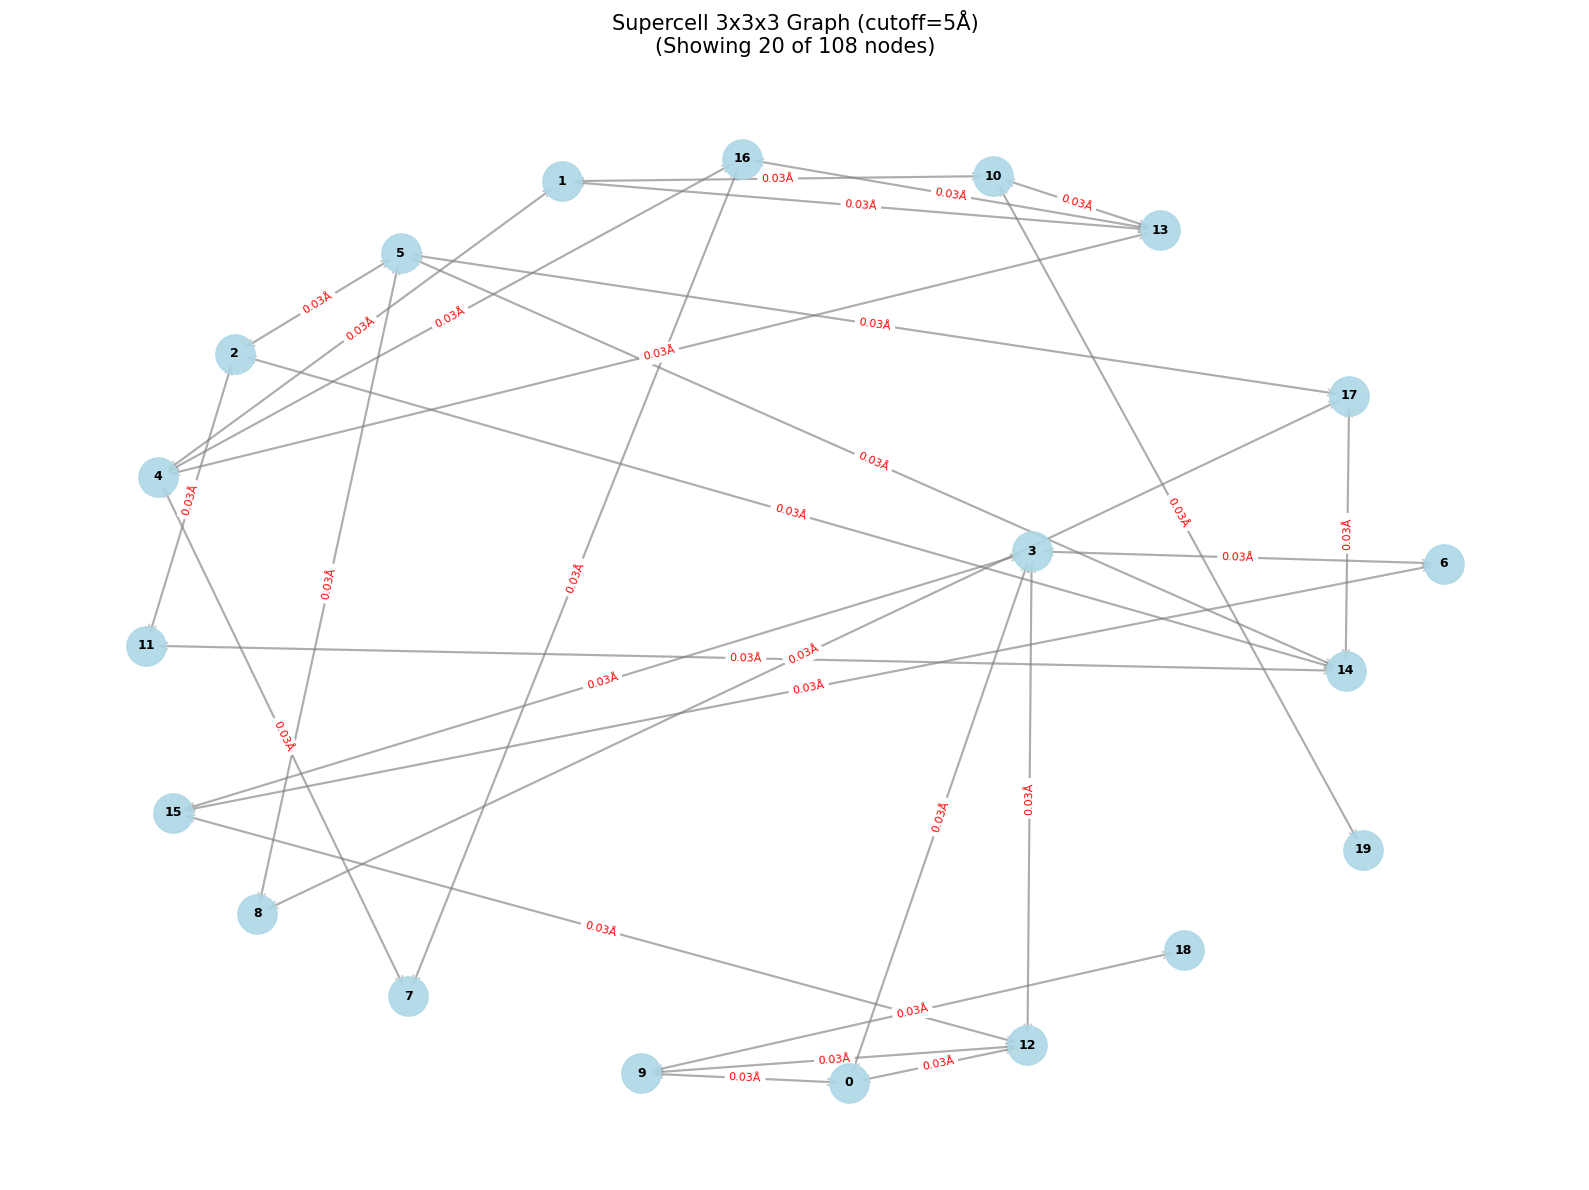

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

# پیدا کردن یه ساختار بزرگتر
for idx in range(len(task.df)):
    n_atoms_check = len(task.df['structure'].iloc[idx].sites)
    if n_atoms_check ==2:
        sample_idx = idx
        break
sample_idx = 4
print(f"Using structure {sample_idx} with {n_atoms_check} atoms")

# ساخت گراف
test_graph = structure_to_graph(task.df['structure'].iloc[sample_idx], 
                                task.df['last phdos peak'].iloc[sample_idx], 
                                df_ptable)

print(f"\n📊 Graph Structure:")
print(f"   Total nodes: {test_graph.num_nodes}")
print(f"   Total edges: {test_graph.num_edges}")
print(f"   Features per node: {test_graph.num_node_features}")

# رسم گراف
G = nx.DiGraph()

# اضافه کردن نودها
for i in range(test_graph.num_nodes):
    G.add_node(i)

# اضافه کردن یال‌ها
edge_list = test_graph.edge_index.t().numpy()
edge_attrs = test_graph.edge_attr.numpy()

for idx, edge in enumerate(edge_list):
    G.add_edge(edge[0], edge[1], weight=edge_attrs[idx][0])

# رسم (فقط زیرمجموعه‌ای برای خوانایی)
subset_size = min(20, test_graph.num_nodes)
subgraph_nodes = list(range(subset_size))
H = G.subgraph(subgraph_nodes)

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(H, k=1.5, iterations=100)

nx.draw_networkx_nodes(H, pos, node_color='lightblue', node_size=800, alpha=0.9)
nx.draw_networkx_edges(H, pos, edge_color='gray', alpha=0.4, 
                       arrows=True, arrowsize=12, arrowstyle='->', width=1.5)
nx.draw_networkx_labels(H, pos, font_size=9, font_weight='bold')

# نمایش فاصله روی یال‌ها
edge_labels = {}
for u, v, data in H.edges(data=True):
    distance = data.get('weight', 0)
    edge_labels[(u, v)] = f"{distance:.2f}Å"

nx.draw_networkx_edge_labels(H, pos, edge_labels, font_size=8, font_color='red')

plt.title(f"Supercell 3x3x3 Graph (cutoff=5Å)\n(Showing {subset_size} of {test_graph.num_nodes} nodes)", fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()

In [35]:
class CustomMessagePassing(nn.Module):
    """
    لایه Message Passing سفارشی:
    پیام = ویژگی_نود_همسایه * ویژگی_یال
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # MLP برای ترکیب پیام‌ها
        self.message_mlp = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim),
            nn.SiLU(),
        )
        
    def forward(self, x, edge_index, edge_attr, pos):
        # edge_index: [2, num_edges]
        # edge_index[0]: source nodes (همسایه‌ها)
        # edge_index[1]: target nodes (نودهای مقصد)
        
        source_nodes = edge_index[0]
        target_nodes = edge_index[1]
        
        # ویژگی نودهای همسایه
        neighbor_features = x[source_nodes]  # [num_edges, hidden_dim]
        
        # ============ ضرب ویژگی همسایه در ویژگی یال ============
        # edge_attr: [num_edges, 1] -> تبدیل به [num_edges, hidden_dim] با تکرار مقدار
        edge_features_expanded = edge_attr.repeat(1, self.hidden_dim)  # [num_edges, hidden_dim]
        messages = neighbor_features * edge_features_expanded  # [num_edges, hidden_dim]
        
        # ============ محاسبه بردار جهت از همسایه به تارگت ============
        # بردار از source به target
        direction_vectors = pos[target_nodes] - pos[source_nodes]  # [num_edges, 3]
        
        # تبدیل پیام به 3 بعدی با ضرب در بردار جهت
        # messages: [num_edges, hidden_dim] -> sum over hidden_dim -> [num_edges, 1]
        message_magnitude = messages.sum(dim=1, keepdim=True)  # [num_edges, 1]
        
        # پیام برداری 3 مولفه‌ای = magnitude * direction
        vectorial_messages = message_magnitude * direction_vectors  # [num_edges, 3]
        
        # ============ جمع بردارهای پیام از همه همسایه‌ها ============
        num_nodes = x.size(0)
        aggregated_vectors = torch.zeros(num_nodes, 3, device=x.device)
        aggregated_vectors.index_add_(0, target_nodes, vectorial_messages)
        
        # محاسبه اندازه بردار خالص
        vector_magnitude = torch.norm(aggregated_vectors, dim=1, keepdim=True)  # [num_nodes, 1]
        
        # ============ Aggregate Messages معمولی ============
        aggregated = torch.zeros(num_nodes, self.hidden_dim, device=x.device)
        aggregated.index_add_(0, target_nodes, messages)
        
        # ترکیب پیام معمولی با اندازه بردار
        combined = torch.cat([aggregated, vector_magnitude], dim=1)  # [num_nodes, hidden_dim + 1]
        
        # اعمال MLP روی پیام‌های جمع شده
        output = self.message_mlp(combined)
        
        return output

class BondAwareGNN(nn.Module):
    """
    مدل با Message Passing سفارشی:
    پیام = ویژگی_نود_همسایه * ویژگی_یال
    """
    def __init__(self, n_node_features=76, edge_dim=1):
        super().__init__()
        hidden = 32
        
        # ============ Node Embeddings ============
        self.node_embedding = nn.Sequential(
            nn.Linear(n_node_features, hidden),
            nn.BatchNorm1d(hidden),
            nn.SiLU(),
            nn.Dropout(0.1),
        )
        
        # ============ Custom Message Passing Layers ============
        self.message_layers = nn.ModuleList([
            CustomMessagePassing(hidden)
            for _ in range(2)
        ])
        
        # Layer norm بعد از هر message passing layer
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden)
            for _ in range(2)
        ])
        
        # ============ Node-Level Attention ============
        self.node_attention = nn.Sequential(
            nn.Linear(hidden, hidden // 4),
            nn.SiLU(),
            nn.Linear(hidden // 4, 1),
            nn.Sigmoid()
        )
        
        # ============ Pooling ============
        from torch_geometric.nn import Set2Set, global_mean_pool, global_max_pool
        self.set2set_pool = Set2Set(hidden, processing_steps=1)
        self.mean_pool = global_mean_pool
        self.max_pool = global_max_pool
        
        # ============ Global Features ============
        self.global_mlp = nn.Sequential(
            nn.Linear(1, hidden // 4),
            nn.SiLU(),
        )
        
        # ============ Final Prediction ============
        # 2*hidden از Set2Set + hidden از mean + hidden از max + hidden//4 از global
        final_input = 4 * hidden + hidden // 4
        
        self.final_mlp = nn.Sequential(
            nn.Linear(final_input, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    
    def forward(self, data):
        x, edge_index, edge_attr, batch, pos = data.x, data.edge_index, data.edge_attr, data.batch, data.pos
        
        # ============ Initial Embeddings ============
        x = self.node_embedding(x)
        
        # ============ Custom Message Passing ============
        for i, (message_layer, layer_norm) in enumerate(zip(self.message_layers, self.layer_norms)):
            x_residual = x
            
            # Message passing با استفاده از pos و edge_attr اصلی
            x = message_layer(x, edge_index, edge_attr, pos)
            
            # Layer normalization
            x = layer_norm(x)
            
            # Residual connection
            if i > 0:
                x = x + 0.3 * x_residual
            
            x = F.silu(x)
        
        # ============ Node-Level Attention ============
        attention_weights = self.node_attention(x)
        x_weighted = x * attention_weights
        
        # ============ فقط روی نودهای اتمی Pooling انجام بشه ============
        # نودهای اتمی: z != 0 (atomic number)
        # نودهای پیوندی: z == 0
        atom_mask = data.z != 0
        
        x_atoms = x_weighted[atom_mask]
        x_atoms_unweighted = x[atom_mask]
        batch_atoms = batch[atom_mask]
        
        # Graph-level pooling فقط روی atom nodes
        x_set2set = self.set2set_pool(x_atoms, batch_atoms)
        x_mean = self.mean_pool(x_atoms_unweighted, batch_atoms)
        x_max = self.max_pool(x_atoms_unweighted, batch_atoms)
        
        # Global features
        global_features = self.global_mlp(data.u)
        
        # ============ Combine & Predict ============
        combined = torch.cat([x_set2set, x_mean, x_max, global_features], dim=1)
        out = self.final_mlp(combined)
        
        return out.squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sample_graph = structure_to_graph(task.df['structure'].iloc[0], task.df['last phdos peak'].iloc[0], df_ptable)
edge_dim = sample_graph.edge_attr.shape[1]
model = BondAwareGNN(n_node_features=n_features, edge_dim=edge_dim).to(device)
print(f"✅ Bond-Aware GNN Model: {sum(p.numel() for p in model.parameters()):,} params")
print(f"   Features:")
print(f"   - Edge-aware message passing (Gaussian distance + angles)")
print(f"   - Node attention mechanism")
print(f"   - Dual pooling (Set2Set + Mean)")
print(f"   - Deep MLP with regularization")


✅ Bond-Aware GNN Model: 94,722 params
   Features:
   - Edge-aware message passing (Gaussian distance + angles)
   - Node attention mechanism
   - Dual pooling (Set2Set + Mean)
   - Deep MLP with regularization


In [36]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        loss = F.mse_loss(model(data), data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            preds.extend(model(data).cpu().numpy())
            targets.extend(data.y.cpu().numpy())
    return mean_absolute_error(targets, preds)

print("✅ Training functions ready")

✅ Training functions ready


In [22]:
from tqdm import tqdm

# Get fold 0 data
fold_num = 2
train_inputs, train_outputs = task.get_train_and_val_data(fold_num)
test_inputs, test_outputs = task.get_test_data(fold_num, include_target=True)

# Convert to graphs
print(f"Converting {len(train_inputs)} train structures to graphs...")
train_graphs = []
for i in tqdm(range(len(train_inputs))):
    graph = structure_to_graph(train_inputs.iloc[i], train_outputs.iloc[i], df_ptable)
    train_graphs.append(graph)

print(f"Converting {len(test_inputs)} test structures to graphs...")
test_graphs = []
for i in tqdm(range(len(test_inputs))):
    graph = structure_to_graph(test_inputs.iloc[i], test_outputs.iloc[i], df_ptable)
    test_graphs.append(graph)


Converting 1012 train structures to graphs...


100%|██████████| 1012/1012 [01:03<00:00, 16.03it/s]


Converting 253 test structures to graphs...


100%|██████████| 253/253 [00:15<00:00, 16.11it/s]


In [ ]:

# Create loaders
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

# Train model با hyperparameters بهتر
model = BondAwareGNN(n_node_features=n_features, edge_dim=edge_dim).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler with better patience
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.6, patience=12, min_lr=5e-7
)

print(f"\n🚀 Training fine-tuned model (200 epochs)...")
print(f"   Previous best: 75.69 | Target: 28.76 cm⁻¹")
best_mae = float('inf')
patience = 0
max_patience = 200

for epoch in range(1000):
    # Train
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        pred = model(data)
        loss = F.mse_loss(pred, data.y)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    
    train_loss = total_loss / len(train_loader.dataset)
    
    # Evaluate every 5 epochs
    if epoch % 5 == 0 or epoch == 199:
        test_mae = evaluate(model, test_loader, device)
        scheduler.step(test_mae)
        current_lr = optimizer.param_groups[0]['lr']
        
        if test_mae < best_mae:
            best_mae = test_mae
            patience = 0
            torch.save(model.state_dict(), f'best_matbench_model_fold{fold_num}.pt')
            print(f"✓ Epoch {epoch:3d} | Train: {train_loss:.2f} | Test: {test_mae:.2f} ⭐ | LR: {current_lr:.6f}")
        else:
            patience += 5
            if epoch % 20 == 0:
                print(f"  Epoch {epoch:3d} | Train: {train_loss:.2f} | Test: {test_mae:.2f} | LR: {current_lr:.6f}")
        
        if patience >= max_patience:
            print(f"\n⚠️ Early stop at epoch {epoch}")
            break

print(f"\n✅ Best MAE: {best_mae:.2f} cm⁻¹")
print(f"   Previous: 75.69 | Target: 28.76 cm⁻¹")
if best_mae < 75.69:
    print(f"   ⬆️ Improved by {75.69 - best_mae:.2f}!")
if best_mae < 28.76:
    print(f"   🎉 BEAT BENCHMARK!")



🚀 Training fine-tuned model (200 epochs)...
   Previous best: 75.69 | Target: 28.76 cm⁻¹
✓ Epoch   0 | Train: 564004.41 | Test: 572.44 ⭐ | LR: 0.001000
✓ Epoch   0 | Train: 564004.41 | Test: 572.44 ⭐ | LR: 0.001000
✓ Epoch   5 | Train: 432773.63 | Test: 427.60 ⭐ | LR: 0.001000
✓ Epoch   5 | Train: 432773.63 | Test: 427.60 ⭐ | LR: 0.001000
✓ Epoch  10 | Train: 243968.06 | Test: 249.47 ⭐ | LR: 0.001000
✓ Epoch  10 | Train: 243968.06 | Test: 249.47 ⭐ | LR: 0.001000
✓ Epoch  15 | Train: 181854.32 | Test: 211.46 ⭐ | LR: 0.001000
✓ Epoch  15 | Train: 181854.32 | Test: 211.46 ⭐ | LR: 0.001000
✓ Epoch  20 | Train: 152006.62 | Test: 199.81 ⭐ | LR: 0.001000
✓ Epoch  20 | Train: 152006.62 | Test: 199.81 ⭐ | LR: 0.001000
✓ Epoch  25 | Train: 132353.95 | Test: 182.42 ⭐ | LR: 0.001000
✓ Epoch  25 | Train: 132353.95 | Test: 182.42 ⭐ | LR: 0.001000
✓ Epoch  30 | Train: 121650.37 | Test: 175.41 ⭐ | LR: 0.001000
✓ Epoch  30 | Train: 121650.37 | Test: 175.41 ⭐ | LR: 0.001000
✓ Epoch  35 | Train: 117300.